In [1]:
import torch

print(f"PyTorch version: {torch.version}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
else:
    print("Running on CPU")


PyTorch version: <module 'torch.version' from 'c:\\Users\\CSECI\\Desktop\\Visual_Encoders_Street_Images\\venv\\Lib\\site-packages\\torch\\version.py'>
CUDA available: True
GPU: NVIDIA T400 4GB
CUDA version: 11.8


In [ ]:
# !pip install transformers torch torchvision pillow matplotlib

In [ ]:
# !pip install huggingface_hub
# from huggingface_hub import login
# login()
# 

In [ ]:
# !git lfs install
# !git clone https://huggingface.co/datasets/chiragp26/RoadSocial

In [ ]:
# !pip install huggingface_hub
# from huggingface_hub import login
# login()
# HF_TOKEN=your_huggingface_token_here

for preprocessing the data

In [7]:
import os
import json
import time
import random
import requests
import cv2
from pathlib import Path
from tqdm import tqdm

# Configuration
base_path = Path('./RoadSocial')
dataset_root = Path('./dataset')

# Option 1 ratio-based subset (total 1500 videos)
target_videos_per_split = {
    'train': 1005,
    'val': 350,
    'test': 145,
}

# Processing controls
frames_per_video = 10
save_video_files = False
video_cache_dir = Path('./video_cache')
request_timeout = 30
max_retries = 3
seed = 42

# Output structure
for split in target_videos_per_split:
    os.makedirs(dataset_root / split / 'metadata', exist_ok=True)
    os.makedirs(dataset_root / split / 'frames', exist_ok=True)

if save_video_files:
    os.makedirs(video_cache_dir, exist_ok=True)

# Resume + logging files
processed_manifest_path = dataset_root / 'processed_videos.json'
failed_manifest_path = dataset_root / 'failed_downloads.json'

if processed_manifest_path.exists():
    with open(processed_manifest_path, 'r', encoding='utf-8') as f:
        processed_videos = set(json.load(f))
else:
    processed_videos = set()

if failed_manifest_path.exists():
    with open(failed_manifest_path, 'r', encoding='utf-8') as f:
        failed_downloads = json.load(f)
else:
    failed_downloads = []


def save_manifests():
    with open(processed_manifest_path, 'w', encoding='utf-8') as f:
        json.dump(sorted(list(processed_videos)), f, indent=2)
    with open(failed_manifest_path, 'w', encoding='utf-8') as f:
        json.dump(failed_downloads, f, indent=2)


def download_video(url, out_path, timeout=30, retries=3):
    for attempt in range(1, retries + 1):
        try:
            response = requests.get(url, stream=True, timeout=timeout)
            response.raise_for_status()
            with open(out_path, 'wb') as f:
                for chunk in response.iter_content(chunk_size=1024 * 1024):
                    if chunk:
                        f.write(chunk)
            return True
        except Exception as e:
            if attempt == retries:
                return False, str(e)
            time.sleep(1.0 * attempt)
    return False, 'unknown error'


def extract_frames(video_path, output_folder, video_name, num_frames=10):
    vidcap = cv2.VideoCapture(str(video_path))
    total_frames = int(vidcap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames <= 0:
        vidcap.release()
        return 0

    frame_indices = [
        int(i * (total_frames - 1) / (num_frames - 1)) if num_frames > 1 else 0
        for i in range(num_frames)
    ]

    written = 0
    stem = Path(video_name).stem
    for i, frame_id in enumerate(frame_indices):
        vidcap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)
        success, image = vidcap.read()
        if success:
            frame_name = f"{stem}_frame{i}.jpg"
            out_path = Path(output_folder) / frame_name
            cv2.imwrite(str(out_path), image)
            written += 1

    vidcap.release()
    return written


random.seed(seed)

for split, target_count in target_videos_per_split.items():
    split_dir = base_path / split
    json_files = list(split_dir.glob('*.json'))

    if not json_files:
        print(f"No metadata files found in {split_dir}")
        continue

    random.shuffle(json_files)
    selected_json_files = json_files[:min(target_count, len(json_files))]

    print(f"\nProcessing split={split} | requested={target_count} | available={len(json_files)} | selected={len(selected_json_files)}")

    processed_in_split = 0
    for json_path in tqdm(selected_json_files, desc=f"{split} videos"):
        try:
            with open(json_path, 'r', encoding='utf-8') as f:
                data = json.load(f)

            video_name = data.get('VideoName', f"{json_path.stem}.mp4")
            video_stem = Path(video_name).stem
            urls = data.get('TweetVideoURLs', [])

            if video_stem in processed_videos:
                processed_in_split += 1
                continue

            # Always save metadata
            meta_out = dataset_root / split / 'metadata' / json_path.name
            with open(meta_out, 'w', encoding='utf-8') as f:
                json.dump(data, f, indent=2)

            if not urls:
                failed_downloads.append({
                    'split': split,
                    'video': video_name,
                    'reason': 'No TweetVideoURLs'
                })
                continue

            temp_video_path = (video_cache_dir / video_name) if save_video_files else (dataset_root / f"__tmp_{video_name}")
            os.makedirs(temp_video_path.parent, exist_ok=True)

            dl_result = download_video(
                urls[0],
                temp_video_path,
                timeout=request_timeout,
                retries=max_retries,
            )

            if dl_result is not True:
                ok, err = dl_result
                failed_downloads.append({
                    'split': split,
                    'video': video_name,
                    'url': urls[0],
                    'reason': err
                })
                if temp_video_path.exists() and not save_video_files:
                    temp_video_path.unlink(missing_ok=True)
                continue

            frames_out = dataset_root / split / 'frames'
            written = extract_frames(temp_video_path, frames_out, video_name, frames_per_video)

            if written > 0:
                processed_videos.add(video_stem)
                processed_in_split += 1
            else:
                failed_downloads.append({
                    'split': split,
                    'video': video_name,
                    'reason': 'No frames extracted'
                })

            # Remove temporary video if caching is disabled
            if temp_video_path.exists() and not save_video_files:
                temp_video_path.unlink(missing_ok=True)

            if processed_in_split % 25 == 0:
                save_manifests()

        except Exception as e:
            failed_downloads.append({
                'split': split,
                'video_json': json_path.name,
                'reason': str(e)
            })

    save_manifests()
    print(f"Completed split {split}: processed={processed_in_split}")

print('\nProcessing complete.')
print(f"Processed videos tracked: {len(processed_videos)}")
print(f"Failed downloads tracked: {len(failed_downloads)}")


Processing split=train | requested=1005 | available=8838 | selected=1005


train videos: 100%|██████████| 1005/1005 [42:42<00:00,  2.55s/it] 


Completed split train: processed=892

Processing split=val | requested=350 | available=3076 | selected=350


val videos: 100%|██████████| 350/350 [15:40<00:00,  2.69s/it]


Completed split val: processed=300

Processing split=test | requested=145 | available=1272 | selected=145


test videos: 100%|██████████| 145/145 [07:05<00:00,  2.93s/it]

Completed split test: processed=119

Processing complete.
Processed videos tracked: 1308
Failed downloads tracked: 189


In [8]:
import json
import re
from collections import Counter, defaultdict
from pathlib import Path

# Build keyword dictionary from metadata text after preprocessing
DATASET_ROOT = Path('./dataset')
OUTPUT_DIR = DATASET_ROOT / 'labeling'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Base label taxonomy for Phase 2
labels = [
    'a street scene',
    'a road with vehicles',
    'a building',
    'a pedestrian on a sidewalk',
    'a traffic light',
    'a rainy road',
    'a highway',
]

# Seed terms per label; script expands these automatically from metadata
seed_keywords = {
    'a street scene': ['street', 'urban', 'city', 'intersection', 'downtown'],
    'a road with vehicles': ['road', 'vehicle', 'car', 'traffic', 'truck', 'bus', 'lane'],
    'a building': ['building', 'apartment', 'tower', 'office', 'facade'],
    'a pedestrian on a sidewalk': ['pedestrian', 'person', 'walker', 'sidewalk', 'crosswalk'],
    'a traffic light': ['traffic light', 'signal', 'red light', 'green light', 'stoplight'],
    'a rainy road': ['rain', 'rainy', 'wet road', 'puddle', 'storm'],
    'a highway': ['highway', 'expressway', 'freeway', 'motorway', 'overpass'],
}

stopwords = {
    'the', 'a', 'an', 'and', 'or', 'to', 'of', 'in', 'on', 'for', 'with', 'at', 'by', 'from',
    'is', 'are', 'was', 'were', 'be', 'being', 'been', 'this', 'that', 'it', 'as', 'into', 'about',
    'what', 'which', 'when', 'where', 'how', 'why', 'who', 'whom', 'whose', 'do', 'does', 'did',
    'can', 'could', 'would', 'should', 'may', 'might', 'will', 'shall', 'not', 'no', 'yes',
    'there', 'their', 'its', 'also', 'than', 'then', 'very', 'just', 'some', 'many', 'few',
    'video', 'image', 'frame', 'clip', 'scene', 'question', 'answer'
}

text_fields = [
    'TweetText', 'TweetDescription', 'TweetTitle', 'Title', 'Description', 'Summary',
    'caption', 'text', 'Narration', 'Transcript'
]

def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r'https?://\\S+|www\\.\\S+', ' ', text)
    text = re.sub(r'[^a-z0-9\\s]', ' ', text)
    text = re.sub(r'\\s+', ' ', text).strip()
    return text

def tokenize(text: str):
    tokens = [t for t in text.split() if len(t) > 2 and t not in stopwords and not t.isdigit()]
    return tokens

def collect_text_from_metadata(meta: dict) -> str:
    chunks = []

    for field in text_fields:
        value = meta.get(field)
        if isinstance(value, str) and value.strip():
            chunks.append(value)

    qas = meta.get('QAs', [])
    if isinstance(qas, list):
        for qa in qas:
            if not isinstance(qa, dict):
                continue
            for key in ('question', 'answer', 'label', 'category', 'scene'):
                value = qa.get(key)
                if isinstance(value, str) and value.strip():
                    chunks.append(value)

    hashtags = meta.get('Hashtags', [])
    if isinstance(hashtags, list):
        for tag in hashtags:
            if isinstance(tag, str) and tag.strip():
                chunks.append(tag)

    return ' '.join(chunks)

metadata_files = sorted((DATASET_ROOT).glob('*/metadata/*.json'))
if not metadata_files:
    raise FileNotFoundError('No metadata files found under ./dataset/*/metadata. Run preprocessing first.')

label_term_counters = {label: Counter() for label in labels}
global_counter = Counter()
records_used = 0

for meta_path in metadata_files:
    with open(meta_path, 'r', encoding='utf-8') as f:
        meta = json.load(f)

    raw_text = collect_text_from_metadata(meta)
    if not raw_text.strip():
        continue

    cleaned = clean_text(raw_text)
    tokens = tokenize(cleaned)
    if not tokens:
        continue

    token_set = set(tokens)
    global_counter.update(tokens)
    records_used += 1

    # Weakly assign this metadata text to one or more labels by seed-term hit
    for label, seeds in seed_keywords.items():
        matched = False
        for seed in seeds:
            seed_clean = clean_text(seed)
            if ' ' in seed_clean:
                if seed_clean in cleaned:
                    matched = True
                    break
            else:
                if seed_clean in token_set:
                    matched = True
                    break
        if matched:
            label_term_counters[label].update(tokens)

# Build expanded keyword dictionary
keyword_dict = {}
for label in labels:
    base = [clean_text(k) for k in seed_keywords.get(label, [])]
    base = [k for k in base if k]

    top_terms = [
        term for term, freq in label_term_counters[label].most_common(120)
        if term not in stopwords and freq >= 3
    ]

    # Keep terms that are relatively informative for this label
    scored_terms = []
    for term in top_terms:
        label_freq = label_term_counters[label][term]
        global_freq = global_counter[term]
        specificity = label_freq / max(global_freq, 1)
        if specificity >= 0.25:
            scored_terms.append(term)

    merged = []
    seen = set()
    for term in base + scored_terms:
        if term not in seen:
            seen.add(term)
            merged.append(term)

    keyword_dict[label] = merged[:30]

# Save machine-readable dictionary
json_out = OUTPUT_DIR / 'phase2_keyword_dictionary.json'
with open(json_out, 'w', encoding='utf-8') as f:
    json.dump(keyword_dict, f, indent=2, ensure_ascii=False)

# Save txt dictionary (easy to copy into Phase 2)
txt_out = OUTPUT_DIR / 'phase2_keyword_dictionary.txt'
with open(txt_out, 'w', encoding='utf-8') as f:
    for label in labels:
        f.write(f"{label}: {', '.join(keyword_dict[label])}\\n")

# Save markdown report for review
md_out = OUTPUT_DIR / 'phase2_keyword_dictionary.md'
with open(md_out, 'w', encoding='utf-8') as f:
    f.write('# Phase 2 Keyword Dictionary\\n\\n')
    f.write(f'- Metadata files scanned: {len(metadata_files)}\\n')
    f.write(f'- Metadata records with usable text: {records_used}\\n\\n')
    for label in labels:
        f.write(f'## {label}\\n')
        if keyword_dict[label]:
            for term in keyword_dict[label]:
                f.write(f'- {term}\\n')
        else:
            f.write('- (no strong terms found; keep seed terms manually)\\n')
        f.write('\\n')

print(f'Scanned metadata files: {len(metadata_files)}')
print(f'Records with usable text: {records_used}')
print(f'Saved JSON dictionary: {json_out}')
print(f'Saved TXT dictionary: {txt_out}')
print(f'Saved Markdown report: {md_out}')

# Ready-to-use variable for Phase 2
phase2_keyword_dictionary = keyword_dict
print('Variable ready: phase2_keyword_dictionary')

Scanned metadata files: 1765
Records with usable text: 0
Saved JSON dictionary: dataset\labeling\phase2_keyword_dictionary.json
Saved TXT dictionary: dataset\labeling\phase2_keyword_dictionary.txt
Saved Markdown report: dataset\labeling\phase2_keyword_dictionary.md
Variable ready: phase2_keyword_dictionary


Phase 1

In [ ]:
import torch
from PIL import Image
import os
import json
import glob
import numpy as np
import matplotlib.pyplot as plt
from transformers import CLIPProcessor, CLIPModel

# STEP 1: LOAD CLIP MODEL
print("Loading CLIP model and processor...")
model_id = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_id)
processor = CLIPProcessor.from_pretrained(model_id)
model.eval() # Set to evaluation mode

# STEP 2: DEFINE BASE LABELS
labels = [
    "a street scene",
    "a road with vehicles",
    "a building",
    "a pedestrian on a sidewalk",
    "a traffic light",
    "a rainy road",
    "a highway"
]

# STEP 3: LOAD KEYWORD DICTIONARY GENERATED FROM METADATA TEXT
keyword_dict_path = "./dataset/labeling/phase2_keyword_dictionary.json"
if os.path.exists(keyword_dict_path):
    with open(keyword_dict_path, 'r', encoding='utf-8') as f:
        keyword_dict = json.load(f)
else:
    keyword_dict = {label: [label] for label in labels}

def build_prompts_for_label(label, keywords, max_keywords=6):
    selected_keywords = [k for k in keywords[:max_keywords] if k and k != label]
    keyword_text = ', '.join(selected_keywords)
    prompts = [
        f"a photo of {label}",
        f"a street scene showing {label}",
        f"{label}, {keyword_text}" if keyword_text else f"{label}",
    ]
    return prompts

label_prompts = {}
for label in labels:
    label_prompts[label] = build_prompts_for_label(label, keyword_dict.get(label, [label]))

# STEP 4: LOAD DATA FROM DATASET FOLDER
dataset_path = "./dataset/train/frames"
image_paths = sorted(glob.glob(os.path.join(dataset_path, "*.jpg")))[:5] # Take first 5 for validation

if not image_paths:
    print(f"No images found in {dataset_path}. Please ensure the previous processing step finished successfully.")
else:
    print(f"Found {len(image_paths)} images. Starting Phase 1 Inference...\n")

    for img_path in image_paths:
        image = Image.open(img_path).convert("RGB")

        # Build prompts from the keyword dictionary for this image
        prompts = []
        prompt_to_label = []
        for label in labels:
            for prompt in label_prompts[label]:
                prompts.append(prompt)
                prompt_to_label.append(label)

        inputs = processor(text=prompts, images=image, return_tensors="pt", padding=True)

        with torch.no_grad():
            outputs = model(**inputs)
            logits_per_image = outputs.logits_per_image[0]
            prompt_probs = logits_per_image.softmax(dim=0).cpu().numpy()

        label_scores = {label: 0.0 for label in labels}
        for idx, label in enumerate(prompt_to_label):
            label_scores[label] += float(prompt_probs[idx])

        best_label = max(label_scores, key=label_scores.get)
        confidence = label_scores[best_label]

        print(f"Image: {os.path.basename(img_path)}")
        print(f"Predicted label: \"{best_label}\"")
        print(f"Confidence Score: {confidence:.4f}")
        print("Top Scores:")
        for label, score in sorted(label_scores.items(), key=lambda item: item[1], reverse=True)[:3]:
            print(f" - {label}: {score:.4f}")
        print("-" * 40)

Loading CLIP model and processor...


c:\Users\CSECI\Desktop\Visual_Encoders_Street_Images\venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\CSECI\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 26250.68it/s]
CLIPModel LO

No images found in /content/dataset/train/frames. Please ensure the previous processing step finished successfully.


In [ ]:
Phase 2

In [11]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import json
from transformers import CLIPProcessor, CLIPModel
from tqdm import tqdm

# 1. PREPARE DATASET CLASS
class RoadSocialDataset(Dataset):
    def __init__(self, dataset_root, split, processor):
        self.dataset_root = dataset_root
        self.split = split
        self.processor = processor
        self.data = []

        meta_dir = os.path.join(dataset_root, split, 'metadata')
        frame_dir = os.path.join(dataset_root, split, 'frames')

        # Map frames to their metadata (using the first frame for this phase)
        for meta_file in os.listdir(meta_dir):
            with open(os.path.join(meta_dir, meta_file), 'r') as f:
                meta = json.load(f)

            video_name = meta.get('VideoName', meta_file.replace('.json', '.mp4')).split('.')[0]
            # Finding the first frame extracted for this video
            frame_path = os.path.join(frame_dir, f"{video_name}_frame0.jpg")

            if os.path.exists(frame_path):
                # Use the first QA question as the text label for training alignment
                if meta.get('QAs') and len(meta['QAs']) > 0:
                    text = meta['QAs'][0].get('question', 'a street scene')
                    self.data.append((frame_path, text))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, text = self.data[idx]
        image = Image.open(img_path).convert("RGB")
        inputs = self.processor(text=[text], images=image, return_tensors="pt", padding='max_length', truncation=True)
        return {
            'pixel_values': inputs['pixel_values'].squeeze(0),
            'input_ids': inputs['input_ids'].squeeze(0),
            'attention_mask': inputs['attention_mask'].squeeze(0)
        }

# 2. INITIALIZE MODEL & DATA
device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_id).to(device)
processor = CLIPProcessor.from_pretrained(model_id)

# Phase 2 Rule: Freeze encoders, train projection layers
for param in model.vision_model.parameters(): param.requires_grad = False
for param in model.text_model.parameters(): param.requires_grad = False

train_ds = RoadSocialDataset("./dataset", "train", processor)
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)

# 3. LOSS & OPTIMIZER
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)
loss_img = nn.CrossEntropyLoss()
loss_txt = nn.CrossEntropyLoss()

# 4. TRAINING LOOP
print(f"Starting Phase 2 Training on {len(train_ds)} samples...")
epochs = 20
model.train()

for epoch in range(epochs):
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        optimizer.zero_grad()

        pixel_values = batch['pixel_values'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        outputs = model(input_ids=input_ids, pixel_values=pixel_values, attention_mask=attention_mask, return_loss=True)

        # Contrastive similarity matrix is internal to CLIPModel forward when return_loss=True
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Average Loss: {total_loss/len(train_loader):.4f}")

print("Fine-tuning complete. Model is now optimized for the RoadSocial dataset.")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 54539.11it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Starting Phase 2 Training on 979 samples...


Epoch 1/20: 100%|██████████| 123/123 [00:35<00:00,  3.47it/s]


Epoch 1 Average Loss: 2.4217


Epoch 2/20: 100%|██████████| 123/123 [00:35<00:00,  3.48it/s]


...

Epoch 8 Average Loss: 2.0843


Epoch 9/20: 100%|██████████| 123/123 [00:35<00:00,  3.50it/s]


Epoch 9 Average Loss: 2.0821


Epoch 10/20:  71%|███████   | 87/123 [00:25<00:10,  3.38it/s]


KeyboardInterrupt: 

In [ ]:
Phase 3

--- Phase 3: Post-Training Inference Results ---


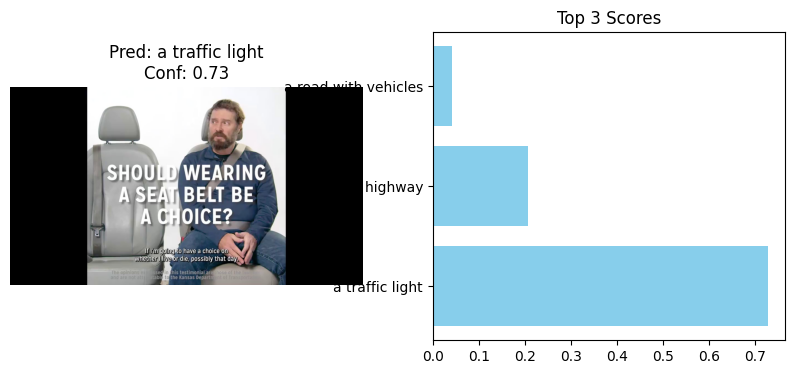

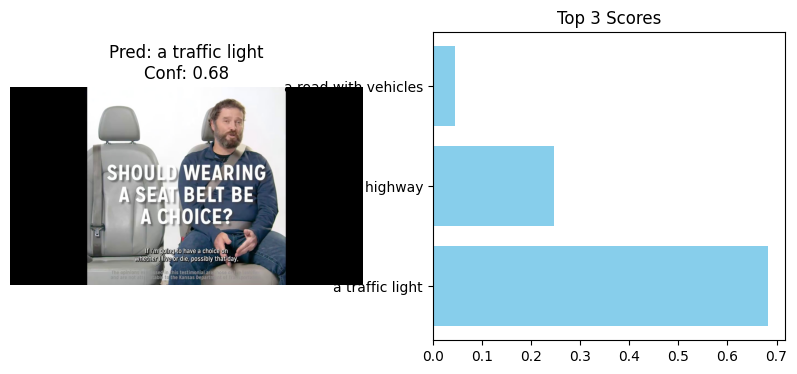


--- Phase 3: Zero-Shot Generalization Test ---


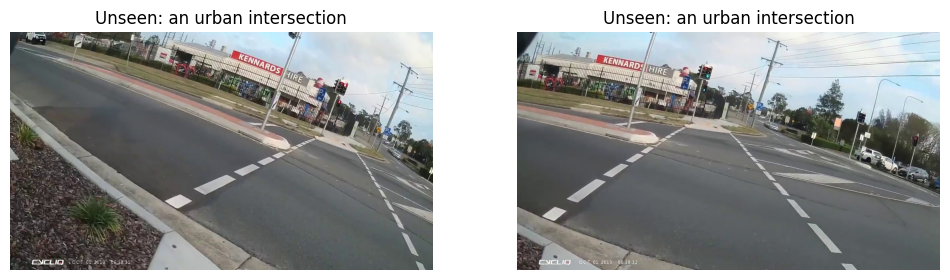


--- Final Evaluation Summary (Sample Size: 50) ---
Total: 500 | Noise: 190 | Relevant: 310 | Accuracy: 62.00%


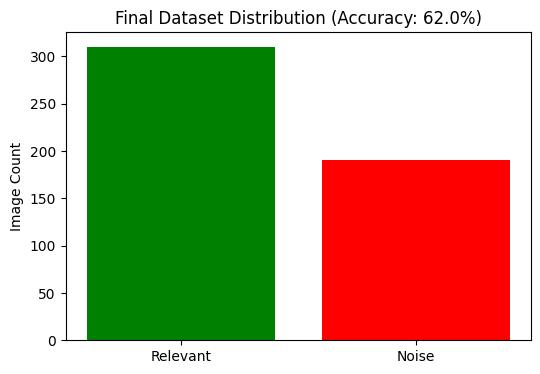

In [10]:
import torch
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
import random
from glob import glob

# Helper for inference
def run_inference(image_path, labels):
    image = Image.open(image_path).convert("RGB")
    inputs = processor(text=labels, images=image, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        probs = outputs.logits_per_image.softmax(dim=1).cpu().numpy()[0]
    return image, probs

# --- PART 1: POST-TRAINING VISUALIZATION ---
print("--- Phase 3: Post-Training Inference Results ---")
val_labels = ["a street scene", "a road with vehicles", "a building", "a pedestrian on a sidewalk", "a traffic light", "a rainy road", "a highway"]
test_image_dir = "./dataset/train/frames"
test_images = sorted(glob(os.path.join(test_image_dir, "*.jpg")))[:2]

for img_path in test_images:
    img, probs = run_inference(img_path, val_labels)
    top_idx = np.argmax(probs)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f"Pred: {val_labels[top_idx]}\nConf: {probs[top_idx]:.2f}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    top3_idx = probs.argsort()[-3:][::-1]
    plt.barh([val_labels[i] for i in top3_idx], probs[top3_idx], color='skyblue')
    plt.title("Top 3 Scores")
    plt.show()

# --- PART 2: ZERO-SHOT GENERALIZATION ---
print("\n--- Phase 3: Zero-Shot Generalization Test ---")
zero_shot_labels = ["an urban intersection", "a car dashboard view", "nighttime city driving"]
unseen_images = sorted(glob("./dataset/test/frames/*.jpg"))[:2]

plt.figure(figsize=(12, 4))
for i, img_path in enumerate(unseen_images):
    img, probs = run_inference(img_path, zero_shot_labels)
    plt.subplot(1, 2, i+1)
    plt.imshow(img)
    plt.title(f"Unseen: {zero_shot_labels[np.argmax(probs)]}")
    plt.axis('off')
plt.show()

# --- PART 3: FINAL PIPELINE ACCURACY ---
print("\n--- Final Evaluation Summary (Sample Size: 50) ---")
refined_labels = val_labels + ["an unrelated or blurry image"]
CONFIDENCE_THRESHOLD, SAMPLE_SIZE = 0.35, 500
all_frames = glob("./dataset/*/frames/*.jpg")
sampled_frames = random.sample(all_frames, min(len(all_frames), SAMPLE_SIZE))

relevant_count, noise_count = 0, 0
for img_path in sampled_frames:
    _, probs = run_inference(img_path, refined_labels)
    top_idx = np.argmax(probs)
    if (probs[top_idx] < CONFIDENCE_THRESHOLD) or (refined_labels[top_idx] == "an unrelated or blurry image"):
        noise_count += 1
    else:
        relevant_count += 1

accuracy = (relevant_count / len(sampled_frames)) * 100
print(f"Total: {len(sampled_frames)} | Noise: {noise_count} | Relevant: {relevant_count} | Accuracy: {accuracy:.2f}%")

# Summary Chart
plt.figure(figsize=(6, 4))
plt.bar(['Relevant', 'Noise'], [relevant_count, noise_count], color=['green', 'red'])
plt.title(f"Final Dataset Distribution (Accuracy: {accuracy:.1f}%)")
plt.ylabel("Image Count")
plt.show()